In [1]:
# Import necessary libraries for clustering
from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('C:/Users/Admin/Desktop/Data Mining/data_for_kdm912s_assessment_3_2025/task3Data.csv')

In [3]:
dataset

,Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3
0,16/12/2006;17:24:00;4.216;0.418;234.840;18.400...
1,16/12/2006;17:25:00;5.360;0.436;233.630;23.000...
2,16/12/2006;17:26:00;5.374;0.498;233.290;23.000...
3,16/12/2006;17:27:00;5.388;0.502;233.740;23.000...
4,16/12/2006;17:28:00;3.666;0.528;235.680;15.800...
...,...
2075254,26/11/2010;20:58:00;0.946;0.000;240.430;4.000;...
2075255,26/11/2010;20:59:00;0.944;0.000;240.000;4.000;...
2075256,26/11/2010;21:00:00;0.938;0.000;239.820;3.800;...
2075257,26/11/2010;21:01:00;0.934;0.000;239.700;3.800;...


In [4]:
# Split the single column by ';'
dataset = dataset[dataset.columns[0]].str.split(';', expand=True)

In [5]:
# Rename the columns
dataset.columns = [
    'Date', 'Time', 'Global_active_power', 'Global_reactive_power',
    'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

In [6]:
# Convert numeric columns to numbers
numeric_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
dataset[numeric_cols] = dataset[numeric_cols].apply(pd.to_numeric, errors='coerce')


In [7]:
dataset

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [8]:
dataset1 = dataset.drop(['Date', 'Time'], axis=1)

In [9]:
dataset1

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...
2075254,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2075255,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2075256,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2075257,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [10]:
dataset1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 110.8 MB


In [11]:
print(dataset1.isnull().sum())

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [12]:
# Drop rows with ANY missing values because they are 0.0125 %
dataset2 = dataset1.dropna()
print("Missing values after cleaning:")
print(dataset2.isnull().sum())

Missing values after cleaning:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [16]:
# Randomly select 20,000 rows from dataset2
dataset3 = dataset2.sample(n=100000, random_state=42)
scaler = StandardScaler()
dataset3 = scaler.fit_transform(dataset3)

print(f"Data shape for clustering: {dataset3.shape}")


Data shape for clustering: (100000, 7)


In [17]:
print(f"Scaled data shape: {dataset3.shape}")
print(f"Scaled data type: {type(dataset3)}")

# Verify scaling worked
print(f"Mean of scaled features: {np.mean(dataset3, axis=0).round(4)}")
print(f"Std of scaled features: {np.std(dataset3, axis=0).round(4)}")

Scaled data shape: (100000, 7)
Scaled data type: <class 'numpy.ndarray'>
Mean of scaled features: [ 0. -0.  0. -0. -0.  0. -0.]
Std of scaled features: [1. 1. 1. 1. 1. 1. 1.]


In [21]:

print("K-MEANS CLUSTERING ANALYSIS")
print("=" * 50)

# Test a wider range of clusters
k_range = range(2, 6)
wcss = []
silhouette_scores = []
cluster_models = {}
cluster_characteristics = {}

for k in k_range:
    # Use better parameters
    kmeans = KMeans(n_clusters=k, 
                   random_state=42, 
                   n_init=10,
                   init='k-means++')
    
    cluster_labels = kmeans.fit_predict(dataset3)
    
    # Store the model
    cluster_models[k] = {
        'model': kmeans,
        'labels': cluster_labels
    }
    
    # Calculate metrics
    wcss.append(kmeans.inertia_)
    silhouette_avg = silhouette_score(dataset3, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
    print(f"\nK={k}:")
    print(f"  WCSS: {kmeans.inertia_:.2f}")
    print(f"  Silhouette Score: {silhouette_avg:.4f}")
    
    # Cluster sizes with better formatting
    unique, counts = np.unique(cluster_labels, return_counts=True)
    cluster_info = []
    for cluster_num, count in zip(unique, counts):
        percentage = (count / len(dataset3)) * 100
        cluster_info.append(f"Cluster {cluster_num}: {count:,} ({percentage:.1f}%)")
    print(f"  Cluster sizes: {', '.join(cluster_info)}")
    
    # Calculate distances for cluster characteristics
    distances = cdist(dataset3, kmeans.cluster_centers_, 'euclidean')
    min_dist = distances.min(axis=1)
    avg_dist = distances.mean(axis=1)
    max_dist = distances.max(axis=1)
    
    # Calculate distances between cluster centers
    center_distances = cdist(kmeans.cluster_centers_, kmeans.cluster_centers_, 'euclidean')
    
    # Find central objects (closest to centroids)
    central_objects = []
    for i in range(k):
        cluster_points = dataset3[cluster_labels == i]
        if len(cluster_points) > 0:
            distances_to_center = cdist(cluster_points, [kmeans.cluster_centers_[i]], 'euclidean').flatten()
            central_idx = np.argmin(distances_to_center)
            central_objects.append(central_idx)
        else:
            central_objects.append(None)
    
    # Store characteristics for this k
    cluster_characteristics[k] = {
        'cluster_centroids': kmeans.cluster_centers_,
        'distances_between_centroids': center_distances,
        'central_objects': central_objects,
        'cluster_sizes': counts,
        'within_cluster_variance': kmeans.inertia_,
        'min_distance_to_centroid': min_dist.mean(),
        'avg_distance_to_centroid': avg_dist.mean(),
        'max_distance_to_centroid': max_dist.mean(),
        'silhouette_score': silhouette_avg
    }

# Display detailed characteristics for each k
feature_names = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for k in k_range:
    print(f"\n{'='*60}")
    print(f"CLUSTER CHARACTERISTICS FOR K = {k}")
    print(f"{'='*60}")
    
    chars = cluster_characteristics[k]
    
    print(f"\n1. CLUSTER CENTROIDS (scaled values):")
    for i, centroid in enumerate(chars['cluster_centroids']):
        print(f"   Cluster {i}: {[f'{val:.4f}' for val in centroid]}")
    
    print(f"\n2. DISTANCES BETWEEN CLUSTER CENTROIDS:")
    print("   " + "\\t".join([f"C{i}" for i in range(k)]))
    for i in range(k):
        row = "\\t".join([f"{chars['distances_between_centroids'][i,j]:.4f}" for j in range(k)])
        print(f"   C{i}\\t{row}")
    
    print(f"\n3. CENTRAL OBJECTS (indices in dataset):")
    for i, obj_idx in enumerate(chars['central_objects']):
        print(f"   Cluster {i}: Object {obj_idx}")
    
    print(f"\n4. NUMBER OF OBJECTS IN EACH CLUSTER:")
    for i, size in enumerate(chars['cluster_sizes']):
        percentage = (size / len(dataset3)) * 100
        print(f"   Cluster {i}: {size} objects ({percentage:.1f}%)")
    
    print(f"\n5. WITHIN CLUSTER VARIANCE (WCSS): {chars['within_cluster_variance']:.2f}")
    
    print(f"\n6. DISTANCE STATISTICS:")
    print(f"   Minimum distance to centroid: {chars['min_distance_to_centroid']:.4f}")
    print(f"   Average distance to centroid: {chars['avg_distance_to_centroid']:.4f}")
    print(f"   Maximum distance to centroid: {chars['max_distance_to_centroid']:.4f}")
    
    print(f"\n7. COHESION AND SEPARATION:")
    print(f"   Silhouette Score: {chars['silhouette_score']:.4f}")
    
    # Calculate additional separation measure
    avg_inter_cluster_distance = np.mean(chars['distances_between_centroids'][np.triu_indices(k, 1)])
    print(f"   Average inter-cluster distance: {avg_inter_cluster_distance:.4f}")
    
    # Cohesion measure (average within-cluster distance)
    cohesion = chars['avg_distance_to_centroid']
    separation = avg_inter_cluster_distance
    print(f"   Cohesion (avg within-cluster distance): {cohesion:.4f}")
    print(f"   Separation (avg between-cluster distance): {separation:.4f}")
    print(f"   Separation/Cohesion ratio: {separation/cohesion:.4f}")

# Find the best number of clusters based on silhouette score
best_k = k_range[np.argmax(silhouette_scores)]
print(f"\n{'='*60}")
print(f"BEST NUMBER OF CLUSTERS (based on silhouette score): K={best_k}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")

K-MEANS CLUSTERING ANALYSIS

K=2:
  WCSS: 482272.20
  Silhouette Score: 0.4046
  Cluster sizes: Cluster 0: 61,541 (61.5%), Cluster 1: 38,459 (38.5%)

K=3:
  WCSS: 358019.81
  Silhouette Score: 0.4213
  Cluster sizes: Cluster 0: 60,953 (61.0%), Cluster 1: 34,085 (34.1%), Cluster 2: 4,962 (5.0%)

K=4:
  WCSS: 276414.76
  Silhouette Score: 0.4387
  Cluster sizes: Cluster 0: 60,948 (60.9%), Cluster 1: 2,336 (2.3%), Cluster 2: 2,714 (2.7%), Cluster 3: 34,002 (34.0%)

K=5:
  WCSS: 238495.45
  Silhouette Score: 0.3450
  Cluster sizes: Cluster 0: 31,820 (31.8%), Cluster 1: 19,216 (19.2%), Cluster 2: 43,941 (43.9%), Cluster 3: 2,709 (2.7%), Cluster 4: 2,314 (2.3%)

CLUSTER CHARACTERISTICS FOR K = 2

1. CLUSTER CENTROIDS (scaled values):
   Cluster 0: ['-0.6051', '-0.0999', '0.2833', '-0.5977', '-0.1777', '-0.1546', '-0.7017']
   Cluster 1: ['0.9677', '0.1598', '-0.4530', '0.9558', '0.2841', '0.2473', '1.1222']

2. DISTANCES BETWEEN CLUSTER CENTROIDS:
   C0\tC1
   C0\t0.0000\t3.0328
   C1\t3.032

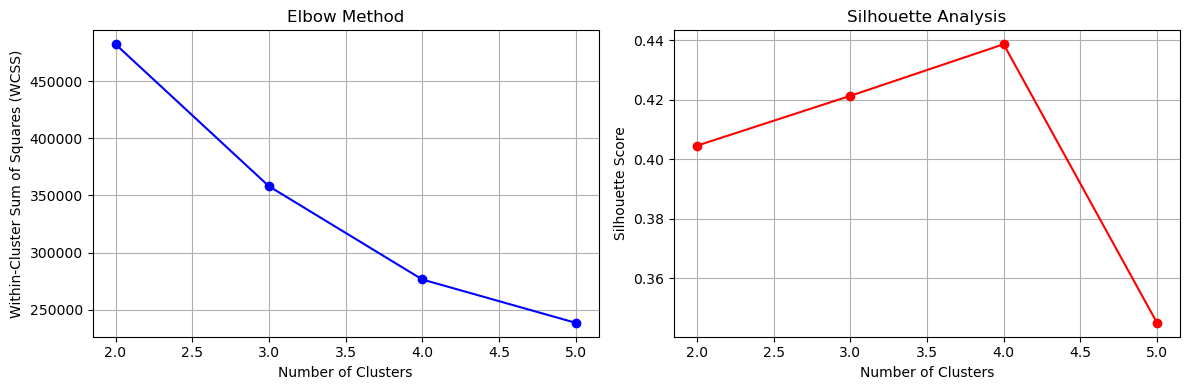


FEATURE INTERPRETATION GUIDE:
Features in the dataset:
  0: Global_active_power
  1: Global_reactive_power
  2: Voltage
  3: Global_intensity
  4: Sub_metering_1
  5: Sub_metering_2
  6: Sub_metering_3

Interpretation of centroids:
  - Positive values: Above average for that feature
  - Negative values: Below average for that feature
  - Magnitude indicates importance in cluster separation


In [20]:
# Create elbow plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True)

plt.tight_layout()
plt.show()

# Display feature importance for interpretation
print(f"\n{'='*60}")
print("FEATURE INTERPRETATION GUIDE:")
print(f"{'='*60}")
print("Features in the dataset:")
for i, name in enumerate(feature_names):
    print(f"  {i}: {name}")

print("\nInterpretation of centroids:")
print("  - Positive values: Above average for that feature")
print("  - Negative values: Below average for that feature")
print("  - Magnitude indicates importance in cluster separation")